# Student Performance Data Cleaning Project

## Objective
Clean and prepare student performance data for analysis using Pandas.

---

## Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

In [22]:
import pandas as pd

# Load dataset
file_path = "C:/Users/LOG IN/Desktop/Student_Performance_Project/data/data.csv"

student_df = pd.read_csv(file_path, sep=";", quotechar='"', encoding='latin1')

print("✅ Data Loaded Successfully")
student_df.head()

✅ Data Loaded Successfully


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## Initial Data Inspection
Understanding the structure and basic information of the dataset.

In [23]:
print(student_df.info())
print(student_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [24]:
student_df.rename(columns={
        "famsize":"family_size",
    "Pstatus":"parent_status",
    "Medu":"mother_education",
    "Fedu": "father_education",
    "Mjob": "mother_job",
    "Fjob":"father_job",
    "famsup":"family_support",
    "famrel": "family_relationship",
    "goout":"going_out",
    "Dalc":"daily_alcohol",
    "Walc":"weekly_alcohol",
    "G1":"first_period_grade",
   "G2":"second_period grade",
    "G3": "final_grade"
    }, inplace=True)

In [25]:
for col in student_df.select_dtypes(include='object').columns:
    student_df[col] = student_df[col].astype(str).str.strip().str.strip('"').str.lower()

print("✅ Text Columns Cleaned")

✅ Text Columns Cleaned


## 🔢 Convert Numeric Columns
Ensuring numeric data is properly formatted.

In [26]:
numeric_cols = [
"age", "mother_education", "father_education", "travel_time", "study_time", "past_failures", "family_relationship", "free_time", "going_out", "weekday_alcohol", "weekend_alcohol", "health_status", "absences", "first_period_grade", "second_period_grade", "final_grade"]


for col in numeric_cols:
    if col in student_df.columns:
        student_df[col] = pd.to_numeric(student_df[col], errors='coerce')

print("✅ Numeric Conversion Done")

✅ Numeric Conversion Done


## ❗ Handling Missing Values
Removing rows with missing values.

In [27]:
print("Missing Values:\n", student_df.isnull().sum())

student_df.dropna(inplace=True)

print("✅ Missing Values Removed")

Missing Values:
 school                 0
sex                    0
age                    0
address                0
family_size            0
parent_status          0
mother_education       0
father_education       0
mother_job             0
father_job             0
reason                 0
guardian               0
traveltime             0
studytime              0
failures               0
schoolsup              0
family_support         0
paid                   0
activities             0
nursery                0
higher                 0
internet               0
romantic               0
family_relationship    0
freetime               0
going_out              0
daily_alcohol          0
weekly_alcohol         0
health                 0
absences               0
first_period_grade     0
second_period grade    0
final_grade            0
dtype: int64
✅ Missing Values Removed


## 🔁 Removing Duplicates

In [28]:
student_df.drop_duplicates(inplace=True)

print("✅ Duplicates Removed")

✅ Duplicates Removed


## 🔄 Standardizing Values

In [29]:
student_df['address'] = student_df['address'].replace({'u': 'urban', 'r': 'rural'})
student_df['school'] = student_df['school'].replace({
    'gp': 'gabriel pereira',
    'ms': 'mousinho da silveira'
})

print("✅ Values Standardized")

✅ Values Standardized


In [30]:
print(student_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   school               649 non-null    object
 1   sex                  649 non-null    object
 2   age                  649 non-null    int64 
 3   address              649 non-null    object
 4   family_size          649 non-null    object
 5   parent_status        649 non-null    object
 6   mother_education     649 non-null    int64 
 7   father_education     649 non-null    int64 
 8   mother_job           649 non-null    object
 9   father_job           649 non-null    object
 10  reason               649 non-null    object
 11  guardian             649 non-null    object
 12  traveltime           649 non-null    int64 
 13  studytime            649 non-null    int64 
 14  failures             649 non-null    int64 
 15  schoolsup            649 non-null    object
 16  family_s

# Inspect dataset Shape and Data types

In [31]:
print("Shape:", student_df.shape)
print("\nData Types:\n", student_df.dtypes)
print("\nFull Info:")
student_df.info()

Shape: (649, 33)

Data Types:
 school                 object
sex                    object
age                     int64
address                object
family_size            object
parent_status          object
mother_education        int64
father_education        int64
mother_job             object
father_job             object
reason                 object
guardian               object
traveltime              int64
studytime               int64
failures                int64
schoolsup              object
family_support         object
paid                   object
activities             object
nursery                object
higher                 object
internet               object
romantic               object
family_relationship     int64
freetime                int64
going_out               int64
daily_alcohol           int64
weekly_alcohol          int64
health                  int64
absences                int64
first_period_grade      int64
second_period grade     int64
final_gra

# 📊 Student Performance Analysis

This project analyzes student performance using Python.  
We calculate average grades, identify high-performing students, and explore relationships between study habits and performance.

##  1. Average Final Grade (G3)

We calculate the average final grade of all students.

In [32]:
avg_g3 = student_df['final_grade'].mean()
print("Average Final Grade (final_grade):", avg_g3)

Average Final Grade (final_grade): 11.906009244992296


## 🔹 2. Students Scoring Above 15

We count how many students scored more than 15 marks.

In [33]:
students_above_15 = student_df[student_df['final_grade'] > 15].shape[0]
print("Number of students scoring above 15:", students_above_15)

Number of students scoring above 15: 82


## 🔹 3. Study Time vs Performance

We check if study time is related to student performance using correlation.

In [34]:
correlation = student_df['studytime'].corr(student_df['final_grade'])
print("Correlation between study time and final_grade:", correlation)

if correlation > 0.5:
    print("Strong positive relationship")
elif correlation > 0:
    print("Weak positive relationship")
elif correlation == 0:
    print("No relationship")
else:
    print("Negative relationship")

Correlation between study time and final_grade: 0.2497886899988628
Weak positive relationship


## 🔹 4. Gender Performance Comparison

We compare the average performance of male and female students.

In [35]:
gender_avg = student_df.groupby('sex')['final_grade'].mean()
print("Average grade by gender:")
print(gender_avg)

best_gender = gender_avg.idxmax()
print("Better performing gender:", best_gender)

Average grade by gender:
sex
f    12.253264
m    11.406015
Name: final_grade, dtype: float64
Better performing gender: f


## Visualizations

In this section, we visualize student performance using different plots:
- Histogram of final grades
- Scatter plot of study time vs grades
- Bar chart comparing gender performance

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

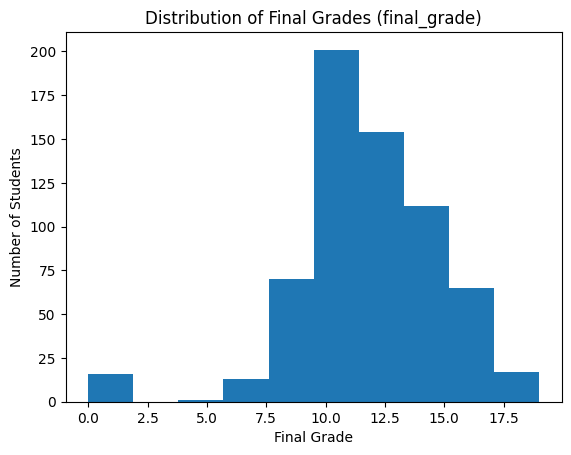

In [37]:
plt.figure()
plt.hist(student_df['final_grade'])
plt.title("Distribution of Final Grades (final_grade)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

### 📊 Scatter Plot: Study Time vs Grades

This plot shows the relationship between study time and final grades.

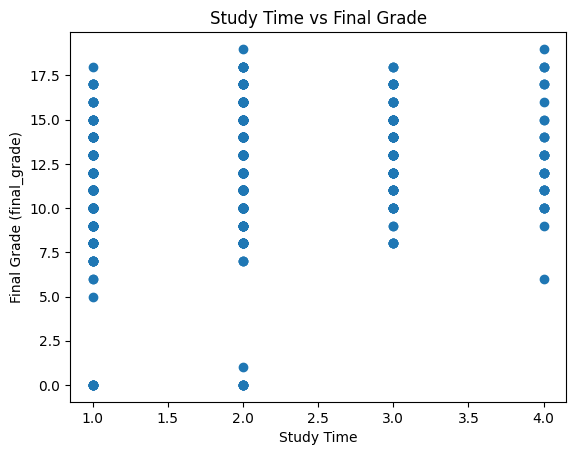

In [38]:
import seaborn as sns
plt.scatter(student_df['studytime'], student_df['final_grade'])
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (final_grade)")
plt.show()

### 📊 Bar Chart: Gender vs Average Score

This compares average performance between male and female students.

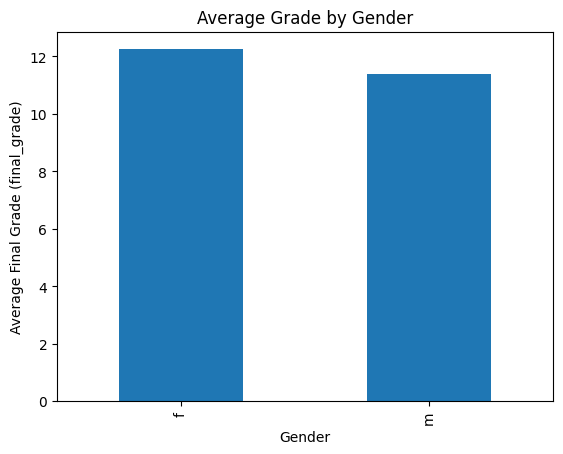

In [39]:
gender_avg = student_df.groupby('sex')['final_grade'].mean()

plt.figure()
gender_avg.plot(kind='bar')
plt.title("Average Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade (final_grade)")
plt.show()

In [40]:
print(type(student_df))

<class 'pandas.core.frame.DataFrame'>


In [20]:
student_df.to_csv("cleaned_student_dataset.csv")